### Import Packages & Load .csv Files

In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD

CORPUS = pd.read_csv("CORPUS.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|")
VOCAB = pd.read_csv("VOCAB.csv", sep="|")

### Sentiment VOCAB_SENT

In [3]:
# Load NRC lexicon (tab-separated)
NRC = pd.read_csv(
    "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
    sep="\t",
    names=["term_str", "emotion", "value"]
)

# Filter for sentiment only
NRC_sent = NRC[
    NRC["emotion"].isin(["positive", "negative"]) &
    (NRC["value"] == 1)
]

# Pivot to wide format
NRC_pivot = NRC_sent.pivot_table(
    index="term_str",
    columns="emotion",
    values="value",
    fill_value=0
).reset_index()

# Create a single sentiment score
NRC_pivot["sentiment"] = NRC_pivot["positive"] - NRC_pivot["negative"]

VOCAB = pd.read_csv("VOCAB.csv", sep="|")

VOCAB["term_str"] = VOCAB["term_str"].astype(str)

VOCAB_SENT = VOCAB.merge(
    NRC_pivot[["term_str", "sentiment"]],
    on="term_str",
    how="inner"
)

VOCAB_SENT.to_csv("VOCAB_SENT.csv", sep="|", index=False)

VOCAB_SENT.head()

,term_str,n,max_pos,max_pos_group,p,i,df,dfidf,porter_stem,stop,sentiment
0,abandoned,7,VBN,VERB,0.000008,16.919387,7,118.435710,abandon,False,-1.0
1,ability,137,NN,NOUN,0.000158,12.628710,125,1578.588743,abil,False,1.0
2,abnormal,9,JJ,ADJ,0.000010,16.556817,7,115.897719,abnorm,False,-1.0
3,abolition,1,NN,NOUN,0.000001,19.726742,1,19.726742,abolit,False,-1.0
4,abortion,8,NN,NOUN,0.000009,16.726742,6,100.360452,abort,False,-1.0


### Sentiment BOW_SENT

In [4]:
# Load BOW
BOW = pd.read_csv("BOW.csv", sep="|")

# Make sure term strings match
BOW["term_str"] = BOW["term_str"].astype(str)

# Join BOW with NRC sentiment scores
BOW_SENT = BOW.merge(
    NRC_pivot[["term_str", "sentiment"]],
    on="term_str",
    how="inner"
)

# Aentiment-weighted count for DOC_SENT construction
BOW_SENT["sentiment_weighted_count"] = BOW_SENT["n"] * BOW_SENT["sentiment"]

# Save
BOW_SENT.to_csv("BOW_SENT.csv", sep="|", index=False)

BOW_SENT.head()

,doc_id,term_str,n,tfidf,sentiment,sentiment_weighted_count
0,0,choice,1,6.034995,1.0,1.0
1,0,dumb,1,9.372865,-1.0,-1.0
2,0,shit,1,8.019228,-1.0,-1.0
3,1,broken,1,7.150473,-1.0,-1.0
4,1,completely,1,5.423849,1.0,1.0


### Sentiment DOC_SENT

In [5]:
# Aggregate sentiment to document level
DOC_SENT = BOW_SENT.groupby("doc_id").agg(
    total_sentiment=("sentiment_weighted_count", "sum"),
    total_terms=("n", "sum")
).reset_index()

# Normalize 
DOC_SENT["avg_sentiment"] = DOC_SENT["total_sentiment"] / DOC_SENT["total_terms"]

# Merge metadata
DOC_SENT = DOC_SENT.merge(
    LIB[["doc_id", "Group", "Source"]],
    on="doc_id",
    how="left"
)

# Save
DOC_SENT.to_csv("DOC_SENT.csv", sep="|", index=False)

DOC_SENT.head()

,doc_id,total_sentiment,total_terms,avg_sentiment,Group,Source
0,0,-1.0,3,-0.333333,Human,reddit_eli5
1,1,-1.0,11,-0.090909,Human,reddit_eli5
2,2,8.0,108,0.074074,Human,reddit_eli5
3,3,7.0,11,0.636364,Human,reddit_eli5
4,4,2.0,2,1.000000,Human,reddit_eli5


### Sentiment Plot

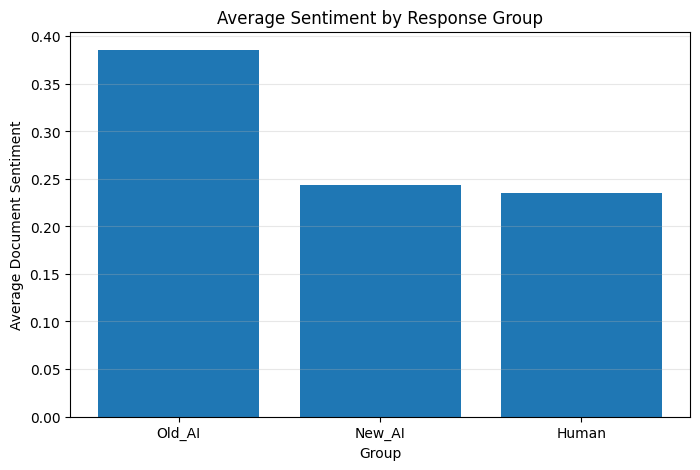

In [6]:
# Mean sentiment by Group
SENT_BY_GROUP = (
    DOC_SENT
    .groupby("Group")["avg_sentiment"]
    .mean()
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    SENT_BY_GROUP["Group"],
    SENT_BY_GROUP["avg_sentiment"]
)

plt.xlabel("Group")
plt.ylabel("Average Document Sentiment")
plt.title("Average Sentiment by Response Group")
plt.grid(axis="y", alpha=0.3)

plt.show()